In [ ]:
# Import required libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [ ]:
# Import zipfile
import zipfile
import os

# Find zip file automatically
zip_file = [f for f in os.listdir() if f.endswith('.zip')][0]

print("Zip file found:", zip_file)

# Extract dataset
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Zip file found: images-20260515T061610Z-3-001.zip
Dataset extracted successfully!


# Task 1: Problem Identification

### Selected Problem Type: Image Classification

This dataset represents an image classification problem because each image belongs to one predefined category.

The classes are:

- normal
- scratch
- dent
- stain

The objective is to classify a product image into its correct defect category.

Since each image has a single label and there are no bounding boxes or segmented regions, image classification is the most suitable computer vision approach.

In [ ]:
# Dataset path
dataset_path = "dataset/images"

# Get only folders (ignore .DS_Store)
classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Classes:", classes)
print("Number of classes:", len(classes))

# Count images per class
image_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    image_counts[class_name] = len(os.listdir(class_path))

# Show image counts
print("Images per class:")
print(image_counts)

Classes: ['stain', 'normal', 'scratch', 'dent']
Number of classes: 4
Images per class:
{'stain': 120, 'normal': 120, 'scratch': 120, 'dent': 120}


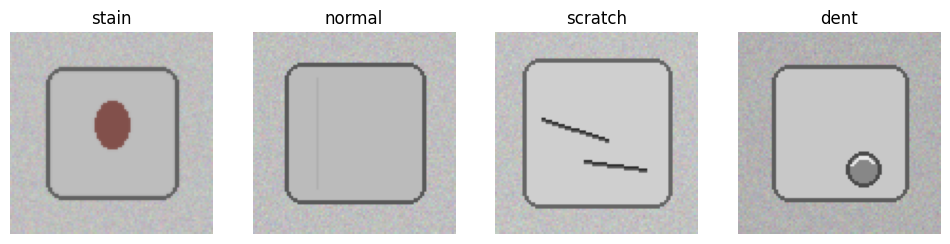

In [ ]:
# Show sample image from each class

plt.figure(figsize=(12, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    # Get first image from folder
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    # Read image
    img = Image.open(image_path)

    # Plot image
    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
# Check image dimensions

sample_image_path = os.path.join(
    dataset_path,
    classes[0],
    os.listdir(os.path.join(dataset_path, classes[0]))[0]
)

img = Image.open(sample_image_path)

print("Image Size (Width, Height):", img.size)
print("Image Shape:", np.array(img).shape)

Image Size (Width, Height): (96, 96)
Image Shape: (96, 96, 3)


# Task 2: Dataset Exploration

The image dataset was explored to understand its structure and distribution.

### Number of Classes
The dataset contains:

- 4 classes

Classes:
- dent
- normal
- scratch
- stain

### Images Per Class
Each class contains:

- 120 images

Total images:

480

### Dataset Balance
The dataset is balanced because each class contains the same number of images.

### Image Dimensions
- Width: 96 pixels
- Height: 96 pixels
- Channels: 3 (RGB)

Sample images from each class were visualized to understand defect characteristics.


In [ ]:
# Load and preprocess images

X = []
y = []

# Label mapping
label_map = {
    'dent': 0,
    'normal': 1,
    'scratch': 2,
    'stain': 3
}

# Read images
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        # Open image
        img = Image.open(image_path)

        # Resize image
        img = img.resize((96, 96))

        # Convert image to array
        img_array = np.array(img)

        # Normalize pixels (0–255 → 0–1)
        img_array = img_array / 255.0

        X.append(img_array)
        y.append(label_map[class_name])

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("Image dataset shape:", X.shape)
print("Label shape:", y.shape)

Image dataset shape: (480, 96, 96, 3)
Label shape: (480,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (384, 96, 96, 3)
Testing data shape: (96, 96, 96, 3)
Training labels shape: (384,)
Testing labels shape: (96,)


# Task 3: Image Preprocessing

Image preprocessing was performed to prepare the dataset for CNN training.

The following preprocessing steps were applied:

### 1. Image Resizing
All images were resized to:

96 × 96 pixels

### 2. Pixel Normalization
Pixel values were normalized from:

0–255 → 0–1

### 3. Label Encoding
Class labels were converted into numerical format.

### 4. Train-Test Split
The dataset was split into:

- 80% Training Data
- 20% Testing Data

Data augmentation was not applied because the dataset was balanced and sufficient for a basic CNN model.

In [ ]:
# Import CNN libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Create CNN model
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(96, 96, 3)
))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer (4 classes)
model.add(Dense(4, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,964 (15.20 MB)

 Trainable params: 3,984,964 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train CNN model

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 441ms/step - accuracy: 0.2248 - loss: 1.6375 - val_accuracy: 0.2338 - val_loss: 1.3821
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 394ms/step - accuracy: 0.3257 - loss: 1.3733 - val_accuracy: 0.2338 - val_loss: 1.3828
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 435ms/step - accuracy: 0.4593 - loss: 1.2486 - val_accuracy: 0.6364 - val_loss: 1.0700
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 422ms/step - accuracy: 0.6873 - loss: 0.9145 - val_accuracy: 0.7273 - val_loss: 0.7246
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 565ms/step - accuracy: 0.7948 - loss: 0.6134 - val_accuracy: 0.8052 - val_loss: 0.5934
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 400ms/step - accuracy: 0.8371 - loss: 0.4412 - val_accuracy: 0.8182 - val_loss: 0.4233
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 511ms/step - accuracy: 0.9283 - loss: 0.2506 - val_accuracy: 0.8182 - val_loss: 0.4181
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 393ms/step - accuracy: 0.9446 - loss: 0.1719 - val_accuracy: 0.

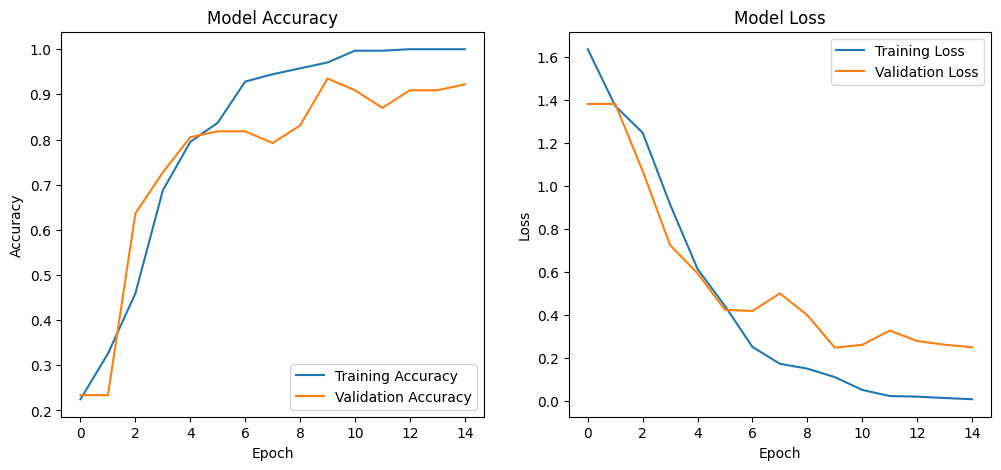

In [ ]:
# Plot accuracy and loss graphs

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Evaluate model on testing data

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.8542 - loss: 0.3269
Test Accuracy: 0.8541666865348816
Test Loss: 0.32688891887664795


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step


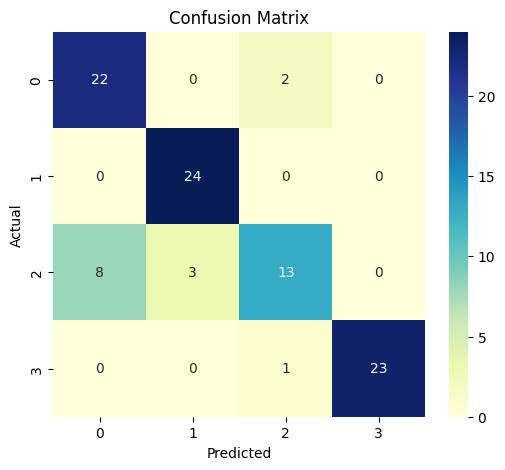

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

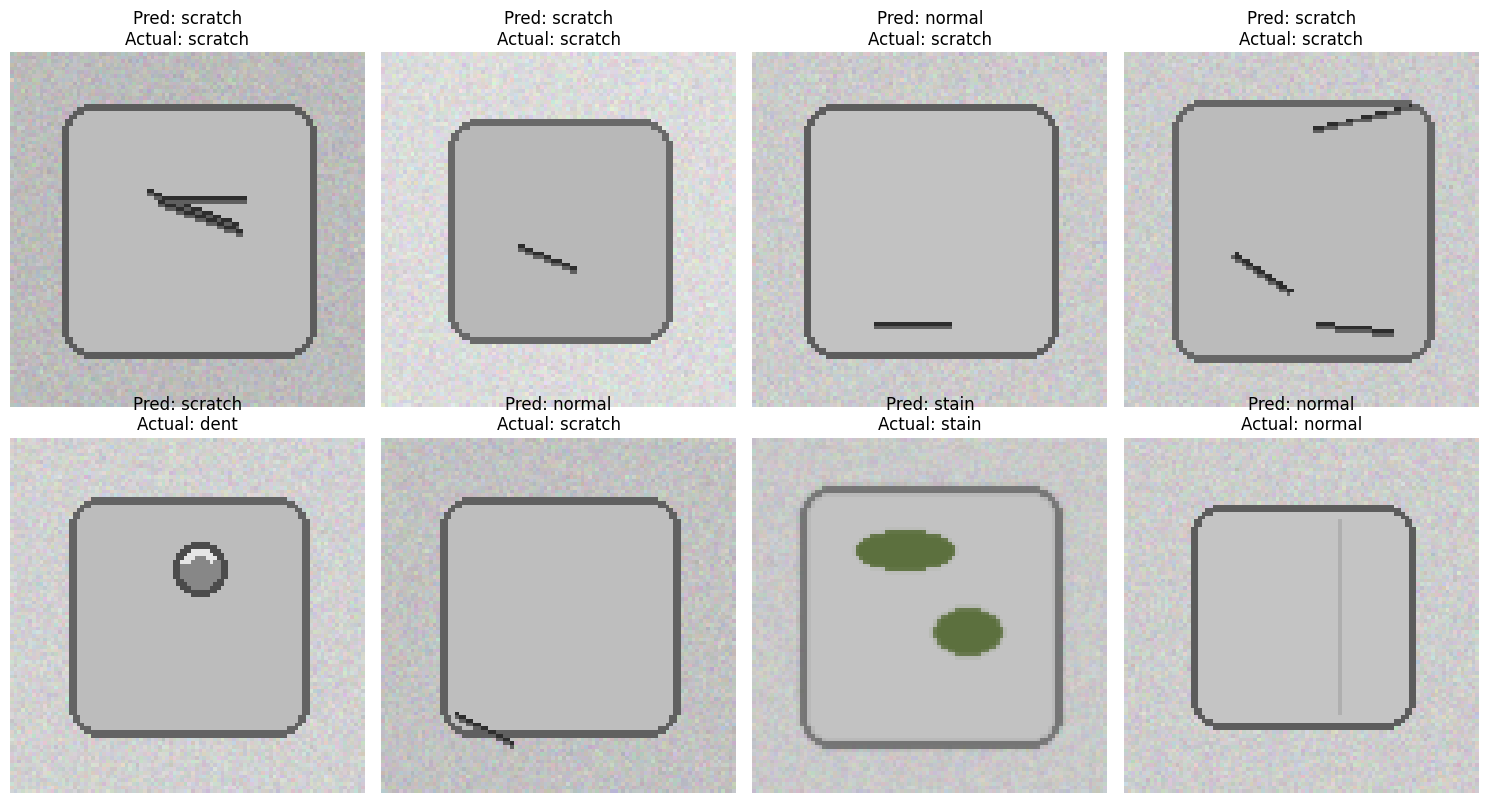

In [ ]:
# Show sample predictions

class_names = ['dent', 'normal', 'scratch', 'stain']

plt.figure(figsize=(15,8))

for i in range(8):  # show 8 predictions
    plt.subplot(2,4,i+1)

    # Show image
    plt.imshow(X_test[i])

    # Predict class
    prediction = model.predict(
        np.expand_dims(X_test[i], axis=0),
        verbose=0
    )

    predicted_class = class_names[np.argmax(prediction)]
    actual_class = class_names[y_test[i]]

    plt.title(
        f"Pred: {predicted_class}\nActual: {actual_class}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 6: CNN Concept Explanation

### What is Convolution?
Convolution is a process where filters are applied to images to detect patterns such as edges, scratches, or shapes.

### Why is Pooling Used?
Pooling reduces image size and computation while keeping important features.

### Why is ReLU Commonly Used in CNNs?
ReLU helps the model learn faster and solves the vanishing gradient problem.

### Why are CNNs Better Than Feed-Forward Networks for Image Data?
CNNs automatically learn image features and spatial relationships, making them more effective for image tasks.



# Task 7: Business Use Case Mapping

## Domain: Manufacturing

This computer vision solution can be used in the manufacturing industry for automated quality inspection.

Products moving through a production line can be captured using cameras, and a CNN-based system can automatically classify defects such as dents, scratches, stains, or normal products.

This helps manufacturers:

- Detect defective products automatically
- Reduce manual inspection effort
- Improve product quality
- Save time and operational costs
- Increase production efficiency

For example, automobile parts, electronic devices, or packaged goods can be inspected using image classification systems to identify damaged products before delivery to customers.

In [ ]:
import os

os.makedirs("part-2-cnn-computer-vision/results", exist_ok=True)
os.makedirs("part-2-cnn-computer-vision/sample_predictions", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


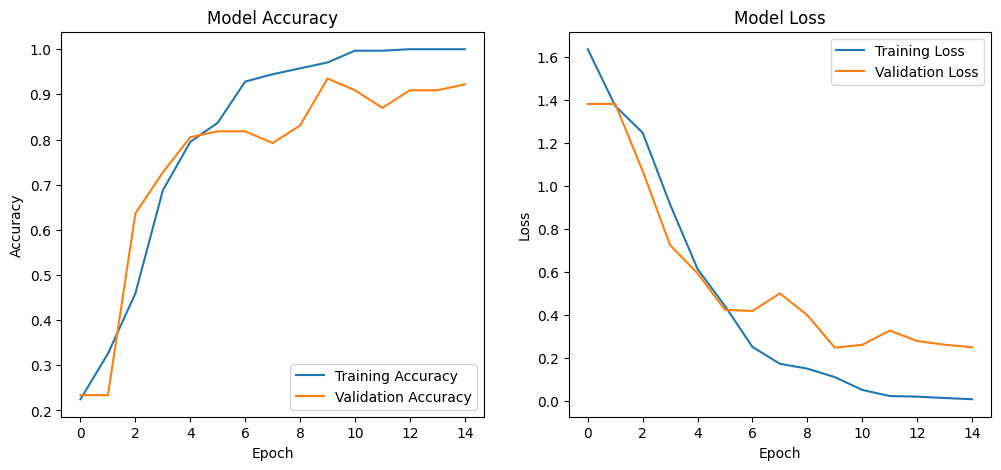

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Save image
plt.savefig(
    "part-2-cnn-computer-vision/results/accuracy_loss_curves.png"
)

plt.show()

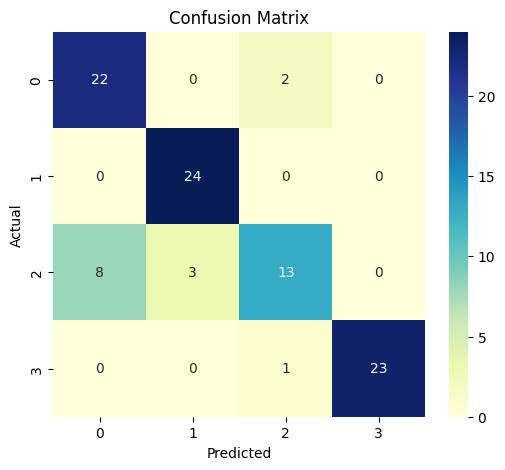

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "part-2-cnn-computer-vision/results/confusion_matrix.png"
)

plt.show()

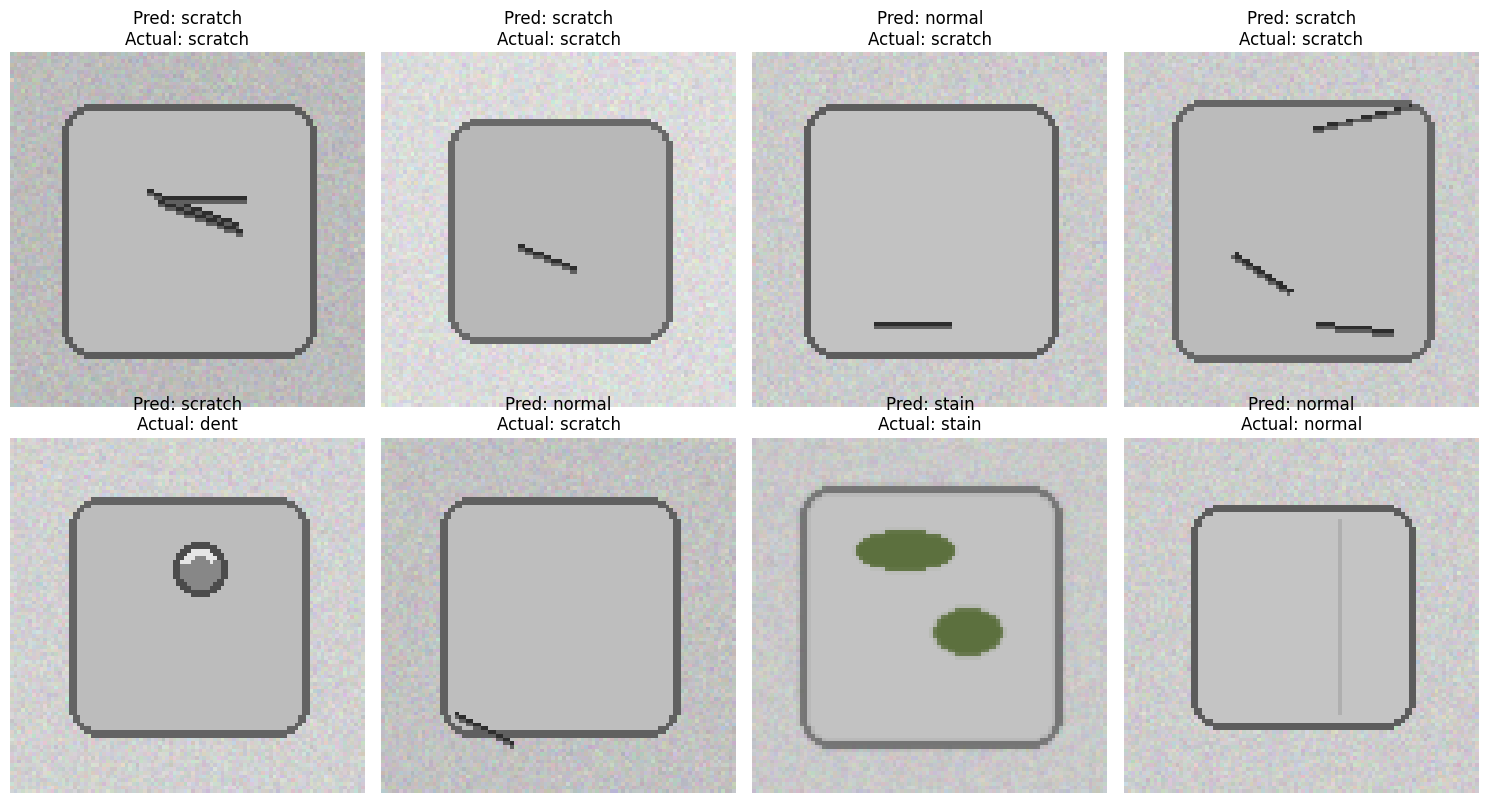

In [ ]:
class_names = ['dent', 'normal', 'scratch', 'stain']

plt.figure(figsize=(15,8))

for i in range(8):
    plt.subplot(2,4,i+1)

    plt.imshow(X_test[i])

    prediction = model.predict(
        np.expand_dims(X_test[i], axis=0),
        verbose=0
    )

    predicted_class = class_names[np.argmax(prediction)]
    actual_class = class_names[y_test[i]]

    plt.title(
        f"Pred: {predicted_class}\nActual: {actual_class}"
    )

    plt.axis("off")

plt.tight_layout()

# Save image
plt.savefig(
    "part-2-cnn-computer-vision/sample_predictions/prediction_outputs.png"
)

plt.show()

In [ ]:
requirements = """
numpy
pandas
matplotlib
seaborn
scikit-learn
tensorflow
pillow
"""

with open(
    "part-2-cnn-computer-vision/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!
